# Observer-Aware FOV Demo

Load a portable metadata fixture, reconstruct the saved red box, and plot both boxes as seen from any observer.

In [93]:
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.time import Time
from sunpy.coordinates import Helioprojective
from sunpy.map import Map, make_fitswcs_header

from pyampp import geometry, io

In [95]:
fixture = Path('data/hmi.M_720s.20201126_195831.E18S19CR.CEA.NAS.GEN.CHR_metadata.h5')
thin = io.load_geometry_contract_and_observer_from_h5(fixture)

obstime   = Time(thin['observer']['ephemeris']['obs_date'])
saved_fov = thin['observer']['fov_box']

red_world = geometry.world_corners_from_geometry_contract(thin['metadata']['geometry_contract'])
print('obstime:', obstime)
print(f"saved FOV centre: xc={float(saved_fov['xc_arcsec']):.1f}\" yc={float(saved_fov['yc_arcsec']):.1f}\"")

obstime: 2020-11-26T19:58:31.300
saved FOV centre: xc=-680.0" yc=-400.0"


## Modify Here
Edit the parameters in the next cell (`observer_name`, FOV overrides, and grid options).

In [99]:
# -- change these to explore -------------------------------------------------
observer_name = 'earth'   # 'earth' | 'stereo-a' | 'stereo-b' | 'solo'
pad_xy_arcsec = 0.0       # extra padding around the inscribed FOV projection (arcsec)

# manual FOV overrides - set to None to use the auto-inscribed value
xc_arcsec_override = None    # e.g. -300.0
yc_arcsec_override = None    # e.g. -500.0
xsize_arcsec_override = None # e.g. 800.0
ysize_arcsec_override = None # e.g. 800.0

# one-shot reset from metadata stored in the fixture
# set True, run the next cell once, then set back to False
revert_to_saved_metadata = False

# optional Stonyhurst overlay (can be slow in some environments)
show_stonyhurst_grid = True
stonyhurst_spacing_deg = 10
# -----------------------------------------------------------------------------

## Re-run Here To Apply
After changing values above, run the next cell to regenerate the plot.

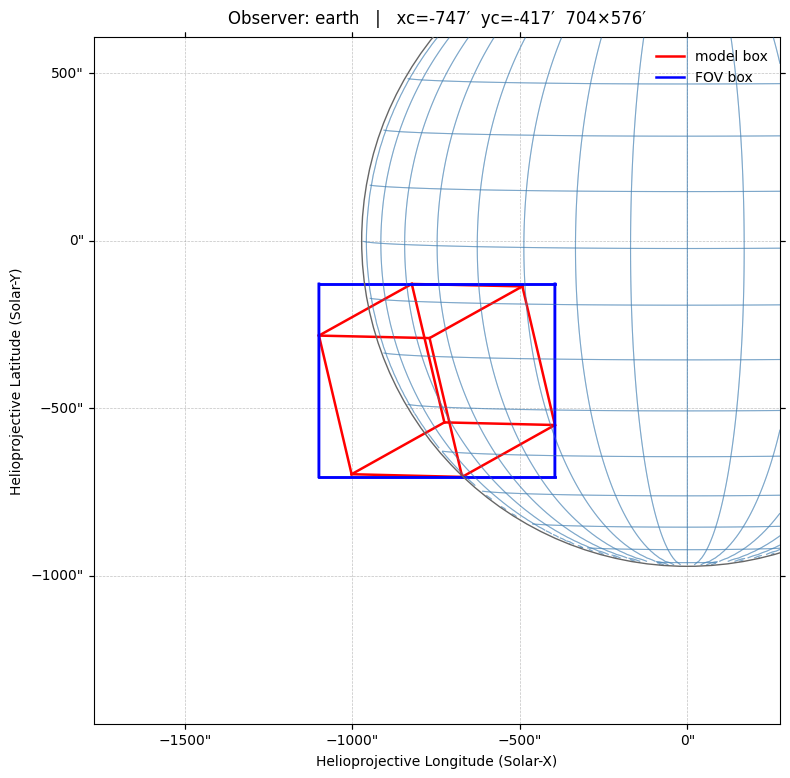

In [100]:
BOX_EDGES = [(0,1),(0,2),(1,3),(2,3),(4,5),(4,6),(5,7),(6,7),(0,4),(1,5),(2,6),(3,7)]

# Safe defaults allow this cell to run even if cell 4 was not re-executed.
show_stonyhurst_grid = globals().get('show_stonyhurst_grid', False)
stonyhurst_spacing_deg = globals().get('stonyhurst_spacing_deg', 10)
revert_to_saved_metadata = globals().get('revert_to_saved_metadata', False)

if revert_to_saved_metadata:
    thin = io.load_geometry_contract_and_observer_from_h5(fixture)
    obstime = Time(thin['observer']['ephemeris']['obs_date'])
    saved_fov = thin['observer']['fov_box']
    red_world = geometry.world_corners_from_geometry_contract(thin['metadata']['geometry_contract'])

    # Saved fixture metadata corresponds to Earth observer.
    observer_name = 'earth'
    pad_xy_arcsec = 0.0

    xc_arcsec_override = float(saved_fov['xc_arcsec'])
    yc_arcsec_override = float(saved_fov['yc_arcsec'])
    xsize_arcsec_override = float(saved_fov['xsize_arcsec'])
    ysize_arcsec_override = float(saved_fov['ysize_arcsec'])

observer = geometry.resolve_named_observer(observer_name, obstime)

# Build the FOV box from the red-box world corners as seen by the current observer
fov_box = geometry.build_fov_box_from_red_box_world(
    red_world, observer=observer, obstime=obstime, pad_xy_arcsec=pad_xy_arcsec,
)

# Apply manual overrides (if set)
if xc_arcsec_override is not None:
    fov_box['xc_arcsec'] = xc_arcsec_override
if yc_arcsec_override is not None:
    fov_box['yc_arcsec'] = yc_arcsec_override
if xsize_arcsec_override is not None:
    fov_box['xsize_arcsec'] = xsize_arcsec_override
if ysize_arcsec_override is not None:
    fov_box['ysize_arcsec'] = ysize_arcsec_override

fov_world = geometry.observer_fov_box_to_world_corners(
    xc_arcsec=fov_box['xc_arcsec'], yc_arcsec=fov_box['yc_arcsec'],
    xsize_arcsec=fov_box['xsize_arcsec'], ysize_arcsec=fov_box['ysize_arcsec'],
    zmin_mm=fov_box['zmin_mm'], zmax_mm=fov_box['zmax_mm'],
    observer=observer, obstime=obstime, target_frame=red_world.frame,
)

# blank solar map centred on the FOV for the WCS projection axes
data = np.zeros((512, 512))
centre = SkyCoord(
    Tx=fov_box['xc_arcsec'] * u.arcsec,
    Ty=fov_box['yc_arcsec'] * u.arcsec,
    frame=Helioprojective(observer=observer, obstime=obstime),
)
smap = Map(data, make_fitswcs_header(data, centre, scale=[4, 4] * u.arcsec / u.pix))

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=smap)
smap.plot(axes=ax, cmap='gray', alpha=0.0)
ax.coords.grid(color='0.6', ls='--', lw=0.5)
smap.draw_limb(axes=ax, color='0.4', lw=1)

# Optional Stonyhurst grid. Use contours mode to avoid expensive line tracing.
if show_stonyhurst_grid:
    overlay = ax.get_coords_overlay('heliographic_stonyhurst')
    overlay[0].set_ticks(spacing=stonyhurst_spacing_deg * u.deg)
    overlay[1].set_ticks(spacing=stonyhurst_spacing_deg * u.deg)
    overlay.grid(grid_type='contours', color='steelblue', alpha=0.45)
    for coord in overlay:
        coord.set_ticklabel_visible(False)
        coord.set_ticks_visible(False)
        coord.set_axislabel('')

for i, edge in enumerate(geometry.project_coordinate_edges_to_observer_hpc(
    red_world, edge_pairs=BOX_EDGES, observer=observer, obstime=obstime,
)):
    ax.plot_coord(edge, 'r-', lw=1.8, label='model box' if i == 0 else None)
for i, edge in enumerate(geometry.project_coordinate_edges_to_observer_hpc(
    fov_world, edge_pairs=BOX_EDGES, observer=observer, obstime=obstime,
)):
    ax.plot_coord(edge, 'b-', lw=1.8, label='FOV box' if i == 0 else None)

ax.set_title(
    f"Observer: {observer_name}   |   "
    f"xc={fov_box['xc_arcsec']:.0f}\N{PRIME}  yc={fov_box['yc_arcsec']:.0f}\N{PRIME}  "
    f"{fov_box['xsize_arcsec']:.0f}\N{MULTIPLICATION SIGN}{fov_box['ysize_arcsec']:.0f}\N{PRIME}",
    fontsize=12,
    pad=10,
)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Edit values in the "Modify Here" section, then run the cell under "Re-run Here To Apply" to refresh the plot.

To reset to saved fixture metadata: set `revert_to_saved_metadata = True`, run the plot cell once, then set it back to `False`.